# Project Citibike network

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import binom

import pandas as pd
import networkx as nx
import community.community_louvain as community_louvain
import networkx.algorithms.community as nx_comm
from collections import defaultdict


# Load the data

In [34]:
# use dtype=str to avoid the "Mixed Type" warning
df = pd.read_csv('JC-202402-citibike-tripdata.csv', dtype={'start_station_id': str, 'end_station_id': str})


# Clean the data

In [ ]:
# remove rows with missing station ids
df = df.dropna(subset=['start_station_id', 'end_station_id'])

# remove self-loops
df = df[df["start_station_id"] != df["end_station_id"]]


Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')


# Create a Weighted Graph

In [ ]:
# A Link is a trip. Weight is the number of trips between two stations
links_df = df.groupby(['start_station_id', 'end_station_id']).size().reset_index(name='weight')
#filter no connection nodes
G_o = nx.from_pandas_edgelist(links_df, 
                            source='start_station_id', 
                            target='end_station_id', 
                            edge_attr='weight')
largest_cc = max(nx.connected_components(G_o), key=len)
G = G_o.subgraph(largest_cc)

# Basic Statistics

In [21]:
N = len(G) #number of nodes
L = len(G.edges) #numb of edges
k = 2*L/N # average degree
C= nx.average_clustering(G)

p = k / (N-1) # calculated possibility

print("numb of nodes", N)
print("number of edges", L)
print("average degree", k )

numb of nodes 134
number of edges 2611
average degree 38.97014925373134


In [22]:
degree_dict = dict(nx.degree(G))
clustering_dict = nx.clustering(G)

In [23]:
df = pd.DataFrame([degree_dict, clustering_dict]).T
df.columns = ["Degree", "Clustering"]
df.head()

,Degree,Clustering
5105.01,5.0,0.700000
5114.06,3.0,0.666667
HB101,70.0,0.797629
8029.28,1.0,0.000000
HB102,80.0,0.738595


In [24]:
K= df.Degree.max()
K

np.float64(83.0)

Text(0.5, 1.0, 'Degree Distribution')

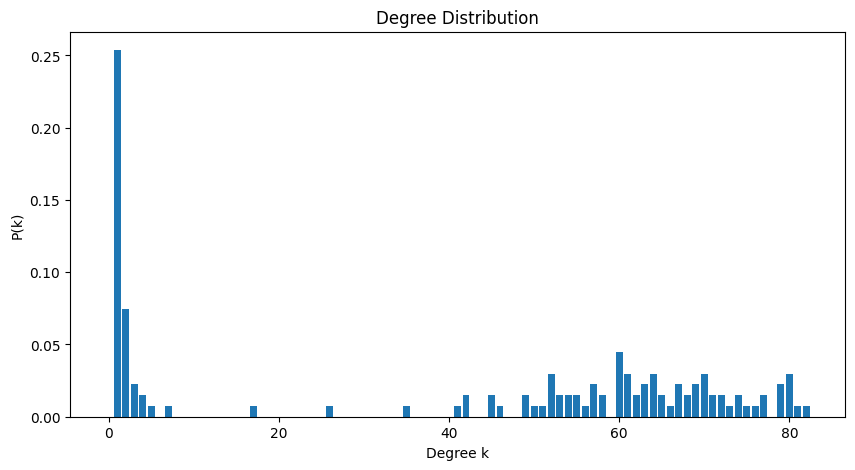

In [25]:
y0, x0 = np.histogram(df.Degree.values, bins= range(int(K)+1), density=True)
plt.figure(figsize=(10, 5))
plt.bar(x0[:-1],y0)
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution')

In [26]:
# compute average clustering and path length for the real graph
C = nx.average_clustering(G)
print("Average clustering coefficient: ", C)
d = nx.average_shortest_path_length(G)
print("Average shortest path length: ", d)


Average clustering coefficient:  0.6023377581450108
Average shortest path length:  1.9667826282123217


# Network Metrics for Visualization

In [27]:
# calculate Betweenness Centrality for node sizing
betweenness = nx.betweenness_centrality(G, weight='weight')
nx.set_node_attributes(G, betweenness, 'betweenness')

# calculate Degree 
degree = dict(G.degree(weight='weight'))
nx.set_node_attributes(G, degree, 'degree_weight')

# Community Detection

In [28]:
partition = community_louvain.best_partition(G, weight='weight')
nx.set_node_attributes(G, partition, "modularity_class")
# convert partition dict to a list of sets for NetworkX
communities = [set() for _ in range(max(partition.values()) + 1)]
for node, community_id in partition.items():
    communities[community_id].add(node)

# Add Centrality Measures

In [29]:
degree_cent = nx.degree_centrality(G)
# use weight='weight' for betweenness to account for trip volume
betweenness_cent = nx.betweenness_centrality(G, weight='weight')

nx.set_node_attributes(G, degree_cent, "degree_centrality")
nx.set_node_attributes(G, betweenness_cent, "betweenness_centrality")

# Export for Gephi

In [30]:
nx.write_gexf(G, "citibike_network_202402.gexf")

# Basic Network Statistics

In [39]:
print(f"Total Stations in Largest Component: {len(G.nodes())}")
print(f"Number of Communities Detected: {len(set(partition.values()))}")

Total Stations in Largest Component: 134
Number of Communities Detected: 3


# Calculate the Modularity Score and Top 5 Hubs

In [42]:
modularity_score = nx_comm.modularity(G, communities, weight='weight')

print(f"Modularity Score: {modularity_score:.4f}")

# Top 5 Hubs (Degree Centrality)
# these are the 'Social Butterflies' of the network with the most connections
top_hubs = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Hubs (Degree):")
for station, value in top_hubs:
    print(f"  Station {station}: {value:.4f}")

Modularity Score: 0.4354

Top 5 Hubs (Degree):
  Station JC066: 0.6241
  Station JC098: 0.6090
  Station HB102: 0.6015
  Station JC009: 0.6015
  Station JC032: 0.6015


# Top 5 Betweenness Centralities

In [45]:
# these are the 'Gatekeepers' that hold different neighborhoods together
top_bridges = sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Betweenness Centralities:")
for station, value in top_bridges:
    print(f"  Station {station}: {value:.4f}")


Top 5 Betweenness Centralities:
  Station JC102: 0.0901
  Station JC002: 0.0732
  Station HB201: 0.0513
  Station HB401: 0.0494
  Station JC110: 0.0473


# ERDOS RENYI RANDOM GRAPH - NULL MODEL1

In [48]:
L_ER = len(G.nodes())
Lmax_ER = L_ER *( L_ER -1 )/ 2
actualL_ER = len(G.edges())
p = actualL_ER/ Lmax_ER

ER = nx.erdos_renyi_graph(L_ER, p, directed=False)

In [50]:
degree_dict_ER = dict(nx.degree(ER))
clustering_dict_ER = nx.clustering(ER)
df_ER = pd.DataFrame([degree_dict_ER, clustering_dict_ER]).T
df_ER.columns = ["Degree", "Clustering"]
df_ER.head()

,Degree,Clustering
0,46.0,0.287923
1,39.0,0.280702
2,39.0,0.276653
3,44.0,0.290698
4,44.0,0.281184


In [52]:
K_ER= df_ER.Degree.max()
K_ER

57.0

Text(0.5, 1.0, 'ER Degree Distribution')

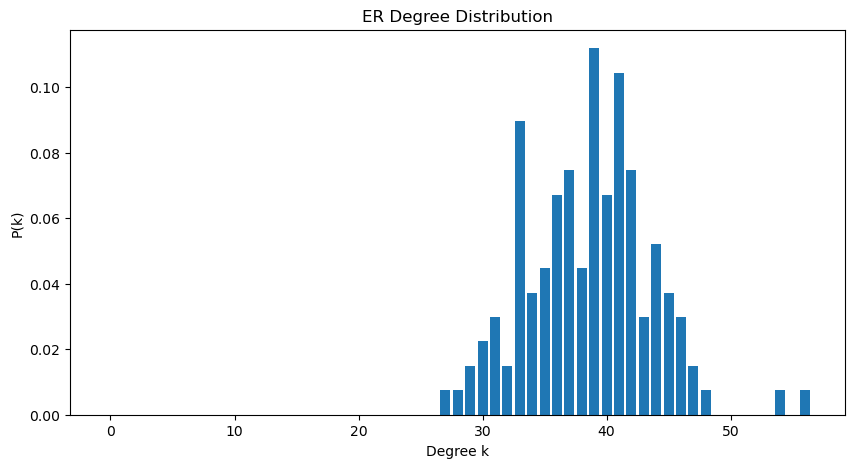

In [54]:
y0_ER, x0_ER = np.histogram(df_ER.Degree.values, bins= range(int(K_ER)+1), density=True)
plt.figure(figsize=(10, 5))
plt.bar(x0_ER[:-1],y0_ER)
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('ER Degree Distribution')

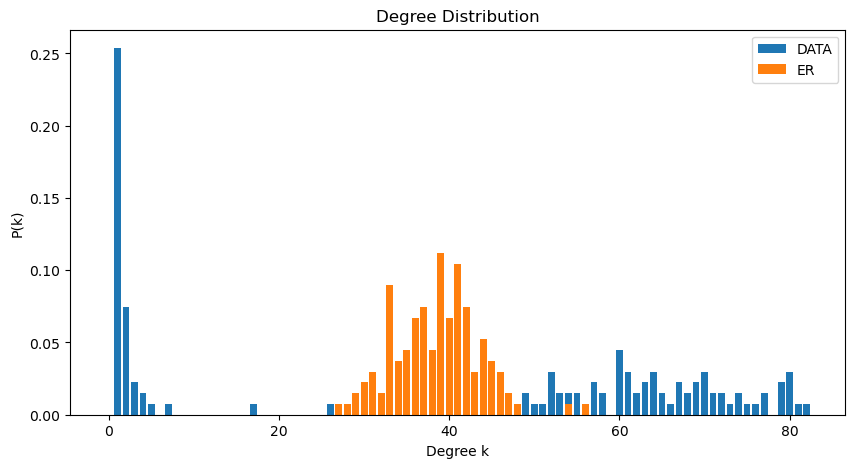

In [56]:
plt.figure(figsize=(10, 5))
y0,x0 = np.histogram(df.Degree.values, bins = range(int(K)+1), density= True)

plt.bar(x0[:-1],y0, label= "DATA")

y0_ER, x0_ER = np.histogram(df_ER.Degree.values, bins= range(int(K_ER)+1), density=True)
plt.bar(x0_ER[:-1],y0_ER, label= "ER")
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution')

plt.legend()

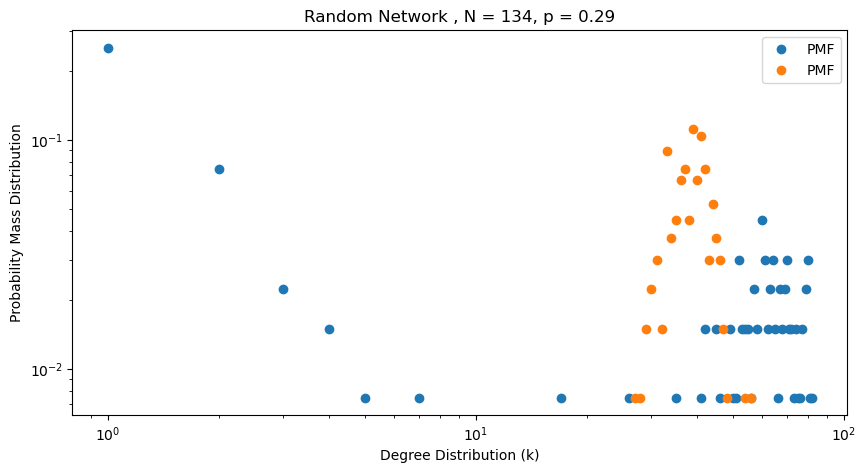

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(x0[:-1], y0, 'o', label = 'PMF')
plt.plot(x0_ER[:-1], y0_ER, 'o', label = 'PMF')

#Applying log to both axis
plt.xscale('log')
plt.yscale('log')

plt.title('Random Network , N = %i, p = %1.2f' %(N,p))
plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')
plt.legend()

In [60]:
C_ER = np.mean(list(nx.clustering(ER).values()))
d_ER = nx.average_shortest_path_length(ER,weight=None)

print("Average Clustering Coefficient: ", C_ER)
print("Average Shortest Path: ", d_ER)

Average Clustering Coefficient:  0.2910906785823671
Average Shortest Path:  1.7099091011109864


# Degree Preservation Configuration Model GRAPH - NULL MODEL2

In [63]:
deg_seq = [G.degree(n) for n in G.nodes()]
Gdp = nx.configuration_model(deg_seq)
Gdp = nx.Graph(Gdp)  
Gdp.remove_edges_from(nx.selfloop_edges(Gdp)) # remove multiple edges

In [65]:
degree_dict_DP = dict(nx.degree(Gdp)) #Creating a dictionary of the degrees of the network
clustering_dict_DP = nx.clustering(Gdp) #Creating a dictionary with the clustering coefficients
df_DP = pd.DataFrame([degree_dict_DP, clustering_dict_DP]).T #Writting this above as a dataframe
df_DP.columns = ['Degree', 'Clustering']
df_DP.head()

,Degree,Clustering
0,5.0,0.500000
1,3.0,0.666667
2,48.0,0.464539
3,1.0,0.000000
4,54.0,0.503843


In [67]:
K_DP = df_DP.Degree.max()
K

83.0

Text(0.5, 1.0, 'DP Degree Distribution')

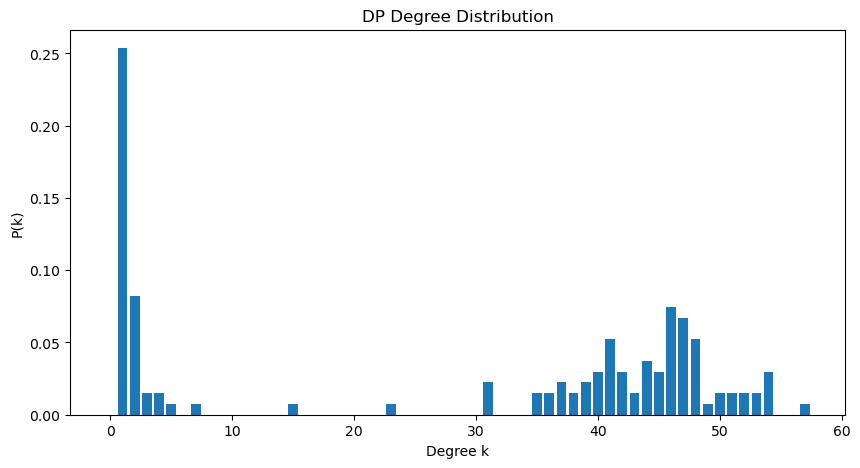

In [69]:
y0_DP, x0_DP = np.histogram(df_DP.Degree.values, bins= range(int(K_DP)+1), density=True)
plt.figure(figsize=(10, 5))
plt.bar(x0_DP[:-1],y0_DP)
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('DP Degree Distribution')

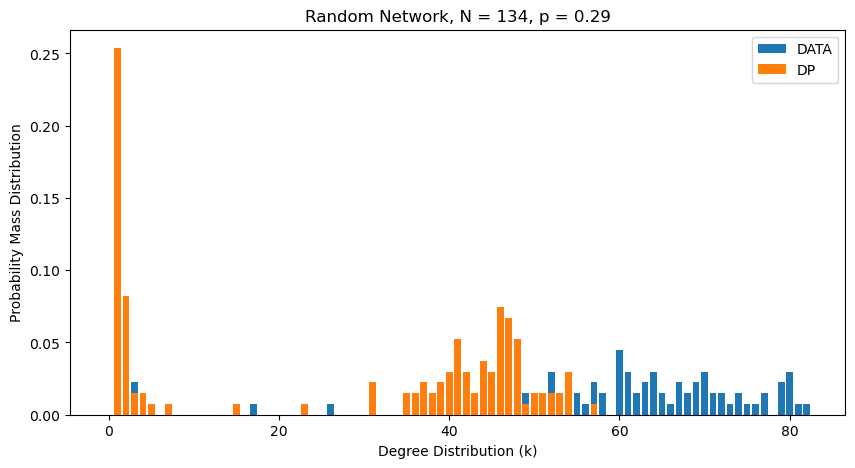

In [71]:
plt.figure(figsize=(10, 5))
y0,x0 = np.histogram(df.Degree.values, bins = range(int(K)+1), density= True)
plt.bar(x0[:-1],y0, label= "DATA")

y0_DP, x0_DP = np.histogram(df_DP.Degree.values, bins= range(int(K_DP)+1), density=True)
plt.bar(x0_DP[:-1],y0_DP, label= "DP")
plt.title('Random Network, N = %i, p = %1.2f' %(N,p))
plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')

plt.legend()

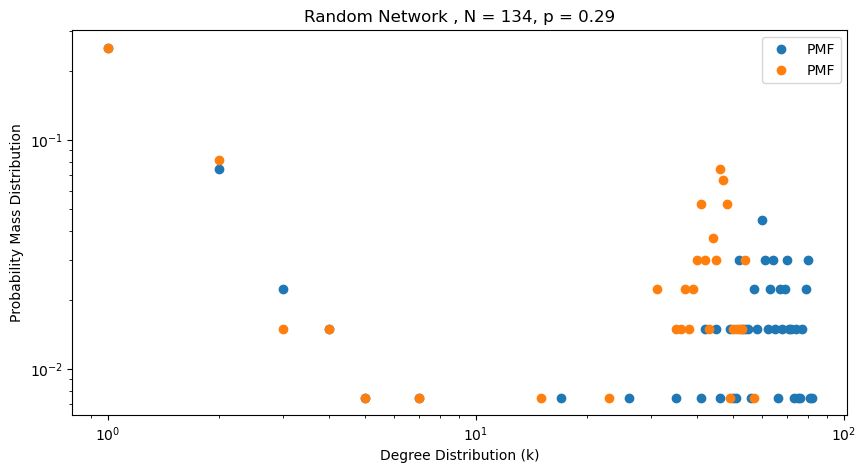

In [73]:
plt.figure(figsize=(10, 5))
plt.plot(x0[:-1], y0, 'o', label = 'PMF')
plt.plot(x0_DP[:-1], y0_DP, 'o', label = 'PMF')

#Applying loh to both axis
plt.xscale('log')
plt.yscale('log')

plt.legend()

plt.title('Random Network , N = %i, p = %1.2f' %(N,p))
plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')
plt.legend()

In [75]:
# function of computing average neighbour degree
def compute_knn(G):
    knn_dict = defaultdict(list)
    for n in G.nodes():
        k = G.degree(n)
        neigh_degs = [G.degree(neigh) for neigh in G.neighbors(n)]
        if neigh_degs:
            knn_dict[k].append(np.mean(neigh_degs))
    knn = {k: np.mean(knn_dict[k]) for k in knn_dict}
    return knn
knn_data = compute_knn(G)

# Ensemble for ER

In [78]:
num_ens = 1000 # use 1000 for more accuracy
clustering_ER = []
short_path_ER = []
degree_histograms_ER = []      # store the full histogram for each graph
max_degree_ER = 0      # track max degree across ensemble to set common bins
knn_lists_ER = []

for i in range(num_ens): 
    
    ER = nx.erdos_renyi_graph(L_ER, p, directed=False)
    C_ER = np.mean(list(nx.clustering(ER).values()))
    # average shortest path (only if connected)
    if nx.is_connected(ER)==True:
        d_ER = nx.average_shortest_path_length(ER,weight=None)
        short_path_ER.append(d_ER)
    clustering_ER.append(C_ER)
    # Degree histogram (probability distribution)
    degrees = [d for n, d in nx.degree(ER)]
    # Choose bins: from 0 to max degree in this graph, align all histograms later
    hist, bins = np.histogram(degrees, bins=range(0, max(degrees)+2), density=True)
    # bins[:-1] are the left edges, store the histogram values aligned by degree
    degree_histograms_ER.append((bins[:-1], hist))  # store bins and probabilities
    
    # update max degree of ER for bin alignment
    if max(degrees) > max_degree_ER:
        max_degree_ER = max(degrees)
    knn_lists_ER.append(compute_knn(ER))

mean_C_ER = np.mean(clustering_ER)
std_C_ER = np.std(clustering_ER)
mean_d_ER = np.mean(short_path_ER)
std_d_ER = np.std(short_path_ER)
print(f"ER clustering: {mean_C_ER:.2f} ± {std_C_ER:.3f}")
print(f"ER avg path: {mean_d_ER:.2f} ± {std_d_ER:.3f}")

ER clustering: 0.29 ± 0.006
ER avg path: 1.71 ± 0.005


In [80]:
# average knn for ER
all_ks = set()
for dic in knn_lists_ER:
    all_ks.update(dic.keys())
knn_ER = {}
for k in all_ks:
    vals = [dic.get(k) for dic in knn_lists_ER if k in dic]
    if vals:
        knn_ER[k] = np.mean(vals)

# Align histograms and compute mean & std of P(k)

In [83]:
# determine common bins 
bins_common_ER = np.arange(0, max_degree_ER+2)
k_values_ER = bins_common_ER[:-1]   # the degree values

# initialize an array to collect probabilities for each graph
prob_matrix_ER = np.zeros((len(degree_histograms_ER), len(k_values_ER)))

for i, (bins_i, probs_i) in enumerate(degree_histograms_ER):
    # probs_i correspond to bins_i (left edges)
    # Map these probabilities into the common bin indices
    for j, k in enumerate(k_values_ER):
        # find if k is within the bins_i range
        if k < len(probs_i):   # because bins_i starts at 0 and goes to max degree of that graph
            prob_matrix_ER[i, j] = probs_i[k] if k < len(probs_i) else 0.0
        else:
            prob_matrix_ER[i, j] = 0.0

# Compute mean and std across the ensemble (axis=0)
mean_p_ER = np.mean(prob_matrix_ER, axis=0)
std_p_ER = np.std(prob_matrix_ER, axis=0)

# Plot the ensemble degree distribution with standard deviation

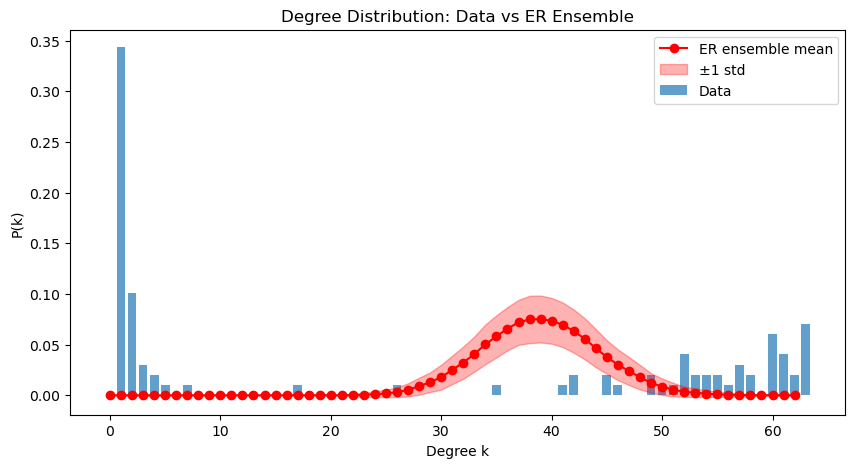

In [86]:
plt.figure(figsize=(10, 5))

# Data distribution 
y_data, x_data = np.histogram(df.Degree.values, bins=range(int(max_degree_ER+2)+1), density=True)
plt.bar(x_data[:-1], y_data, alpha=0.7, label="Data", width=0.8, align='center')

# ER ensemble mean and standaard deviation
plt.plot(k_values_ER, mean_p_ER, 'o-', color='red', label="ER ensemble mean")
plt.fill_between(k_values_ER, mean_p_ER - std_p_ER, mean_p_ER + std_p_ER, alpha=0.3, color='red', label="±1 std")

plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution: Data vs ER Ensemble')
plt.legend()
plt.show()

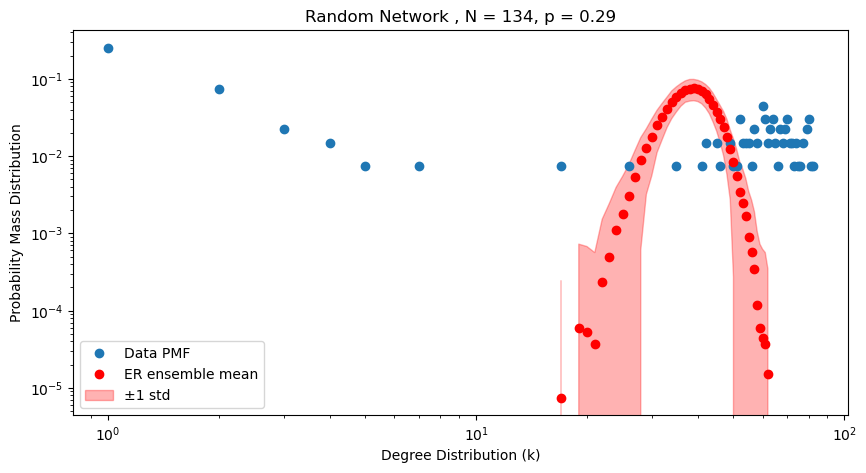

In [88]:
plt.figure(figsize=(10, 5))

plt.plot(x0[:-1], y0, 'o', label = 'Data PMF')

plt.plot(k_values_ER, mean_p_ER, 'o', color='red', label="ER ensemble mean")
plt.fill_between(k_values_ER, mean_p_ER - std_p_ER, mean_p_ER + std_p_ER, alpha=0.3, color='red', label="±1 std")


#Applying log to both axis
plt.xscale('log')
plt.yscale('log')

plt.legend()

plt.title('Random Network , N = %i, p = %1.2f' %(N,p))

plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')
plt.legend()

# Ensemble for DP

In [91]:
clustering_DP = []
short_path_DP = []
degree_histograms_DP = []         # store the full histogram for each graph
max_deg_DP = 0
deg_seq = [G.degree(n) for n in G.nodes()]
knn_lists_DP = []
for i in range(num_ens):
    Gdp = nx.configuration_model(deg_seq)
    Gdp = nx.Graph(Gdp) 
    Gdp.remove_edges_from(nx.selfloop_edges(Gdp))  # remove multiple edges
    clustering_DP.append(nx.average_clustering(Gdp))
    if nx.is_connected(Gdp):
        short_path_DP.append(nx.average_shortest_path_length(Gdp))

    # Degree histogram (probability distribution)
    degs = [d for n, d in Gdp.degree()]
    # Choose bins: from 0 to max degree in this graph, align all histograms later
    hist, bins = np.histogram(degs,
                              bins=np.arange(0, max(degs)+2),
                              density=True)
    # bins[:-1] are the left edges, store the histogram values aligned by degree
    degree_histograms_DP.append((bins[:-1], hist)) # store bins and probabilities
    
    # Track the maximum degree encountered in the ensemble
    if max(degs) > max_deg_DP:
        max_deg_DP = max(degs)
    knn_lists_DP.append(compute_knn(Gdp))
mean_C_DP = np.mean(clustering_DP)
std_C_DP = np.std(clustering_DP)
mean_d_DP = np.mean(short_path_DP)
std_d_DP = np.std(short_path_DP)
print(f"DP clustering: {mean_C_DP:.2f} ± {std_C_DP:.3f}")
print(f"DP avg path: {mean_d_DP:.2f} ± {std_d_DP:.3f}")

DP clustering: 0.38 ± 0.014
DP avg path: 2.15 ± 0.012


# Align histograms and compute mean & std of P(k)

In [94]:
# determine common bins 
bins_common_DP = np.arange(0, max_deg_DP + 2)   # edges 0..k_max_common+1
k_values_DP = bins_common_DP[:-1]                     # integer degrees

# create a matrix to hold probabilities for each graph
prob_matrix_DP = np.zeros((num_ens, len(k_values_DP)))

for i, (bins_i, probs_i) in enumerate(degree_histograms_DP):
    # bins_i are exactly the degrees that appeared in that graph (0..max_i)
    for j, k in enumerate(k_values_DP):
        if k < len(probs_i):
            prob_matrix_DP[i, j] = probs_i[k]   # probs_i[k] corresponds to degree k
        else:
            prob_matrix_DP[i, j] = 0.0

# compute mean and standard deviation across the ensemble for each degree
mean_p_DP = np.mean(prob_matrix_DP, axis=0)
std_p_DP  = np.std(prob_matrix_DP, axis=0)

# Plot the ensemble degree distribution with standard deviation

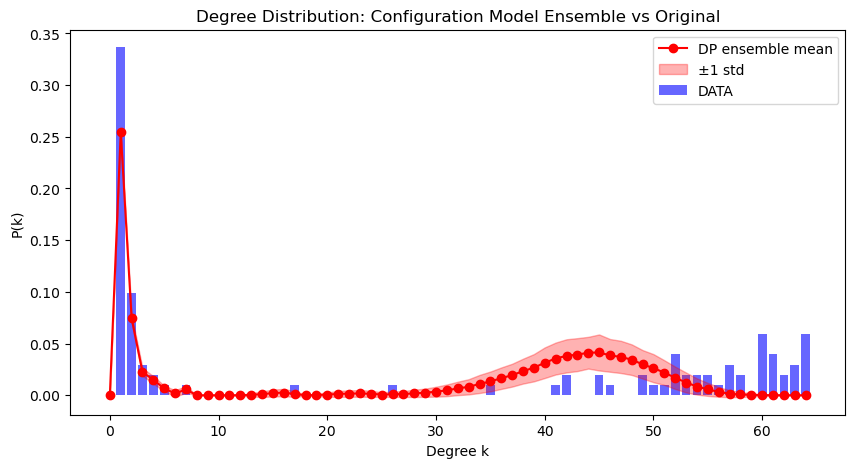

In [97]:
plt.figure(figsize=(10, 5))
# Data distribution 
hist_orig, bins_orig = np.histogram(deg_seq,
                                     bins=np.arange(0, max_deg_DP+2),
                                     density=True)
plt.bar(bins_orig[:-1], hist_orig, alpha=0.6, width=0.8,
        label='DATA', align='center', color='blue')
# DP ensenmble mean and standaard deviation
plt.plot(k_values_DP, mean_p_DP, 'o-', color='red', label="DP ensemble mean")
plt.fill_between(k_values_DP, mean_p_DP - std_p_DP, mean_p_DP + std_p_DP, alpha=0.3, color='red', label="±1 std")


plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution: Configuration Model Ensemble vs Original')
plt.legend()
plt.show()

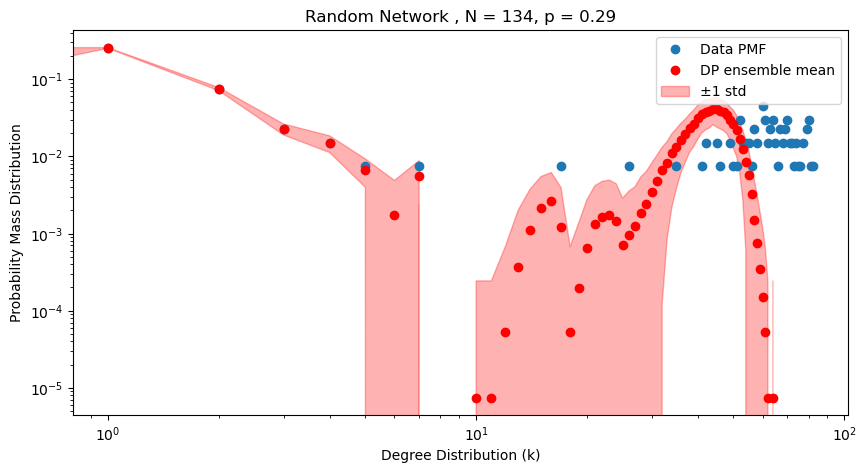

In [99]:
plt.figure(figsize=(10, 5))

plt.plot(x0[:-1], y0, 'o', label = 'Data PMF')

plt.plot(k_values_DP, mean_p_DP, 'o',color='red', label="DP ensemble mean")
plt.fill_between(k_values_DP, mean_p_DP - std_p_DP, mean_p_DP + std_p_DP, alpha=0.3, color='red', label="±1 std")


#Applying log to both axis
plt.xscale('log')
plt.yscale('log')

plt.legend()

plt.title('Random Network , N = %i, p = %1.2f' %(N,p))
#plt.xlim([0,40])
plt.xlabel('Degree Distribution (k)')
plt.ylabel('Probability Mass Distribution')
plt.legend()

In [101]:
# Average knn for DP
all_ks = set()
for dic in knn_lists_DP:
    all_ks.update(dic.keys())
knn_DP = {}
for k in all_ks:
    vals = [dic.get(k) for dic in knn_lists_DP if k in dic]
    if vals:
        knn_DP[k] = np.mean(vals)

# clustering coefficient and average path length between Data, ER ensemble and the DP ensemble 

In [104]:
# Table for global quantities
data_table = {
    'Metric': ['Clustering coefficient', 'Average path length'],
    'Data': [C, d],
    'ER': [f'{mean_C_ER:.2f} ± {std_C_ER:.3f}', f'{mean_d_ER:.2f} ± {std_d_ER:.3f}'],
    'DP': [f'{mean_C_DP:.2f} ± {std_C_DP:.3f}', f'{mean_d_DP:.2f} ± {std_d_DP:.3f}']
}
df_table = pd.DataFrame(data_table)
df_table.set_index('Metric', inplace=True)
df_table

,Data,ER,DP
Metric,,,
Clustering coefficient,0.602338,0.29 ± 0.006,0.38 ± 0.014
Average path length,1.966783,1.71 ± 0.005,2.15 ± 0.012


# average nearest neighbor degree between Data, ER ensemble and the DP ensemble 

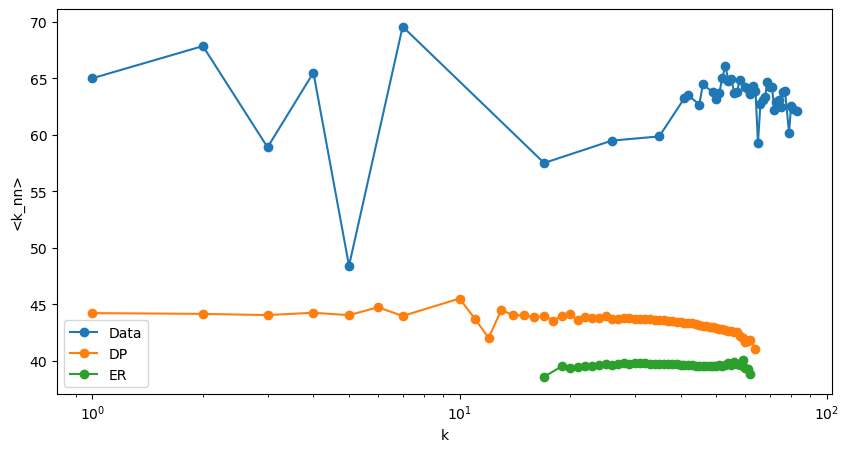

In [107]:
# Plot
fig = plt.figure(figsize=(10,5))
ks = sorted(knn_data)
vals = [knn_data[k] for k in ks]
plt.plot(ks, vals, 'o-', label='Data')
ks_DP = sorted(knn_DP)
vals_DP = [knn_DP[k] for k in ks_DP]
plt.plot(ks_DP, vals_DP, 'o-', label='DP')
ks_ER = sorted(knn_ER)
vals_ER = [knn_ER[k] for k in ks_ER]
plt.plot(ks_ER, vals_ER, 'o-', label='ER')
plt.xlabel('k')
plt.ylabel('<k_nn>')
plt.xscale('log')
plt.legend()
plt.show()

# clustering coefficient between Data, ER ensemble and the DP ensemble 

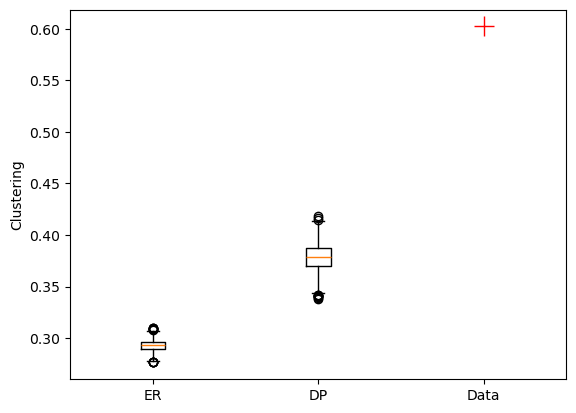

In [110]:

plt.boxplot([clustering_ER,clustering_DP], positions=[1,2])
plt.plot(3,C,'r',marker='+',markersize=15)
ax = plt.gca()
ax.set_xticks([1,2,3],labels=['ER','DP','Data'])
plt.ylabel('Clustering')
plt.xlim([0.5,3.5])
plt.show()

# average shortest path length between Data, ER ensemble and the DP ensemble 

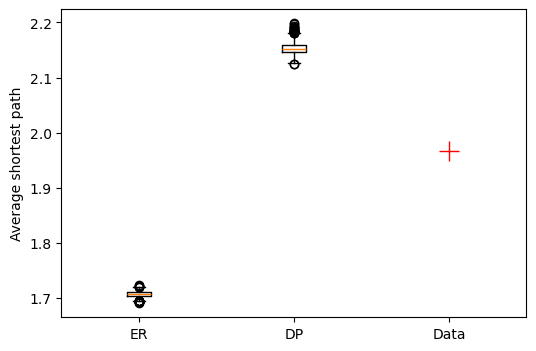

In [115]:
# Shortest path boxplot (using the ensemble data)
fig = plt.figure(figsize=(6,4))

plt.boxplot([short_path_ER,short_path_DP], positions=[1,2])
plt.plot(3,d,'r',marker='+',markersize=15)
ax = plt.gca()
ax.set_xticks([1,2,3],labels=['ER','DP','Data'])
plt.ylabel('Average shortest path')
plt.xlim([0.5,3.5])
plt.show()